# Final Assignment: analyses

This notebook contains the source code for all explainable methods and the analyses. (As you can see a lot of code from the notebook is copied from my training notebook).

## Download dataset

The following cell needs to be ran only once. It downloads and unzips the data. The unzip CLI tool might not be installed by default on Windows, so if you are using windows, please unzip manually into a folder called "data", or see the README.md.

In [353]:
# Downloading the dataset (unzip might not be installed on Windows)
# !curl -L -o ./data.zip https://www.kaggle.com/api/v1/datasets/download/masoudnickparvar/brain-tumor-mri-dataset
# !unzip -d ./data ./data.zip

## Importing libraries

See README.md for installing dependencies :).

In [354]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable
from torch.utils.data import DataLoader
from torchvision import models, datasets, transforms
from sklearn.metrics import balanced_accuracy_score

## Setting the seed

Setting the seed for good reproducability :D

In [355]:
torch.manual_seed(21)  # Using my lucky number :D
np.random.seed(21)

## Setting the device used for analyses

Using `CPU`, because some of the operations require all data to be on CPU, and moving between them all the time creates unnecessary overhead. In addition, we are not training large batches, so using the cpu should suffice.

In [356]:
device = "cpu"

## Preparing the dataset

In [357]:
transform = transforms.Compose(
    [
        transforms.Resize((299, 299)),  # 299 is the minimal image size of InceptionV3
        transforms.ToTensor(),
        # transforms.Normalize(0.5, 0.5)
    ]
)

In [1]:
path = os.path.join("data", "Testing")

NameError: name 'os' is not defined

In [359]:
dataset = datasets.ImageFolder(
    root=path,
    transform=transform
)

In [360]:
loader = DataLoader(dataset, batch_size=16)

## Creating the model

### Loading pre-trained model

In [361]:
model = models.inception_v3(weights=models.Inception_V3_Weights)

### Adding custom classification head

In [362]:
model.fc = nn.Linear(in_features=2048, out_features=2)  # Got the input features from the sourcecode hihi

In [363]:
model = model.to(device)

## Explainable methods

The following tutorial was used for implementing GradCAM: https://medium.com/@stepanulyanin/implementing-grad-cam-in-pytorch-ea0937c31e82, and by looking way to deep into the PyTorch documentation on how to use hooks with pretrained modules, since I can't edit their source code but still need the activations and gradients :( (aaaaaaah).

### GradCAM

In [364]:
def grad_cam(
        model: nn.Module,
        X: torch.Tensor,
        y: int,
        last_conv_layer: nn.Module
) -> torch.Tensor:
    """Creates a Grad-CAM heatmap of a images X, for target label y, using a specified conv layer."""

    def backward_hook(module, in_grad, out_grad):

        # Giving the last layer a new attribute with the activations gradient
        # Indexing because gradients is a 1-tuple
        last_conv_layer.gradients = out_grad[0]

    def forward_hook(module, args, outputs):
        last_conv_layer.activations = outputs  # Fiving the last layer a new attribute with the activations itself


    last_conv_layer.register_full_backward_hook(backward_hook)
    last_conv_layer.register_forward_hook(forward_hook)

    y_pred = model(X)
    y_pred[:, y].backward()  # Calling backwards wrt the desired class.

    gradients = last_conv_layer.gradients[0]
    activations = last_conv_layer.activations.detach()  # Detaching  since numpy can't handle tensors with grad

    pooled_gradients = torch.mean(gradients, (1, 2))

    feature_maps = pooled_gradients.shape[0]
    for i in range(feature_maps):
        activations[:, i, :, :] *= pooled_gradients[i]

    heatmap = torch.mean(activations, dim=1).squeeze()  # Averaging the channels
    heatmap = np.maximum(heatmap, 0)  # Performing linear rectifier
    heatmap /= torch.max(heatmap)  # Normalizing the output of the heatmap between 0 and 1

    return heatmap

### Smoothgrad

In [365]:
def smooth_grad(
        model: nn.Module,
        X: torch.Tensor,
        y: int,
        grad_method: Callable,
        N: int,
        variance: float,
        *args,
        **kwargs,
) -> torch.Tensor:
    """Applies Smoothgrad to a gradient-based method (e.g. Grad-CAM, vanilla gradients)."""

    # Creating the noisy images by adding Gaussian noise
    noisy_images = torch.zeros((N,) + X.shape)
    for i in range(N):
        g = torch.from_numpy(np.random.normal(loc=0, scale=variance, size=X.shape))
        noisy_images[i] = X + g

    # Computing the saliency maps from the gradient based method
    # In my case this will ofc be Grad-CAM, but I like to make
    # things generalized :).
    heatmaps = []
    for i in range(N):
        heatmaps.append(grad_method(model, X, y, *args, **kwargs))

    heatmaps = torch.from_numpy(np.array(heatmaps))
    return torch.mean(heatmaps, dim=0)

## Inspecting explanation results

### Creating dictionary for label names

In [366]:
LABELS = {
    0: "NO TUMOR",
    1: "TUMOR",
}

### Loading model parameters

In [367]:
path = os.path.join("weights", "model-91.pth")
model.load_state_dict(torch.load(path, map_location=device))

<All keys matched successfully>

### Inspecting examples

Predicted: TUMOR
Actual: TUMOR


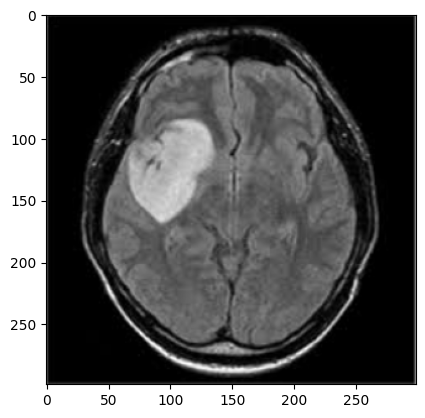

In [368]:
model.eval()

i = 201  # Change this variable to look at different images

X, y = dataset[i]
X = X.unsqueeze(0)
y_pred = torch.argmax(model(X), dim=1)

print(f"Predicted: {LABELS[y_pred.item()]}")
print(f"Actual: {LABELS[y]}")

image_show = X[0].permute((1, 2, 0)).numpy()
plt.imshow(image_show)
plt.show()

In [369]:
y = 1
N = 100
variance = 0.1
last_conv_layer = model.Mixed_7c
image = X[0].unsqueeze(0)
resize = transforms.Resize((299, 299))

/var/folders/gq/4p5dh4bn5ms2p4hx6dp6rzs40000gn/T/ipykernel_17961/3804120781.py:35: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  heatmap = np.maximum(heatmap, 0)  # Performing linear rectifier


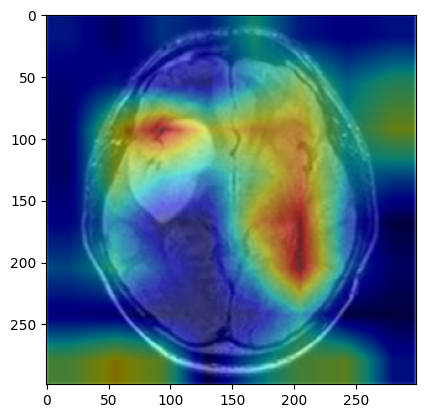

In [370]:
heatmap = grad_cam(model, image, y, last_conv_layer)
interpolated_heatmap = resize(heatmap.unsqueeze(0)).squeeze()
plt.imshow(image_show)
plt.imshow(interpolated_heatmap, cmap='jet', alpha=0.5)
plt.show()

/var/folders/gq/4p5dh4bn5ms2p4hx6dp6rzs40000gn/T/ipykernel_17961/3804120781.py:35: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  heatmap = np.maximum(heatmap, 0)  # Performing linear rectifier


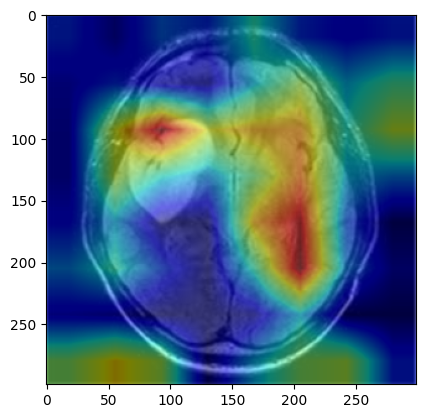

In [371]:
heatmap = smooth_grad(model, image, y, grad_cam, N, variance, last_conv_layer)
interpolated_heatmap = resize(heatmap.unsqueeze(0)).squeeze()
plt.imshow(image_show)
plt.imshow(interpolated_heatmap, cmap='jet', alpha=0.5)
plt.show()